In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


# TASK 1: Problem Identification

In [29]:
## Task 1: Problem Identification

# This dataset represents an *Image Classification* problem.

# Reason:
# - Each image is associated with a single label.
# - No bounding boxes or segmentation masks are provided.
# - The goal is to classify images into predefined categories.

# Hence, this is a multi-class image classification problem

 # TASK 2: Dataset Exploration

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix

In [3]:
# Load Dataset
dataset_path = r"C:\Users\Hrishi\Downloads\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images"

# TASK 3: Image Preprocessing

In [4]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True
)

In [5]:
train_data = train_datagen.flow_from_directory(

    dataset_path,

    classes=['dent', 'normal', 'scratch', 'stain'],

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    subset='training'
)

Found 384 images belonging to 4 classes.


In [6]:
val_data = train_datagen.flow_from_directory(

    dataset_path,

    classes=['dent', 'normal', 'scratch', 'stain'],

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

Found 96 images belonging to 4 classes.


In [7]:
print(train_data.class_indices)

{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


# TASK 4: CNN Model Creation

In [8]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        train_data.num_classes,
        activation='softmax'
    )
])

C:\Users\Hrishi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# TASK 5: Model Training & Evaluation

In [10]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [11]:
history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 470ms/step - accuracy: 0.2422 - loss: 1.8725 - val_accuracy: 0.3542 - val_loss: 1.3689
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 477ms/step - accuracy: 0.3281 - loss: 1.3705 - val_accuracy: 0.4271 - val_loss: 1.3429
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 427ms/step - accuracy: 0.3984 - loss: 1.3162 - val_accuracy: 0.5833 - val_loss: 1.2559
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 403ms/step - accuracy: 0.4661 - loss: 1.1970 - val_accuracy: 0.3542 - val_loss: 1.1584
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 452ms/step - accuracy: 0.5703 - loss: 1.0533 - val_accuracy: 0.6250 - val_loss: 0.9264
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 470ms/step - accuracy: 0.6302 - loss: 0.9000 - val_accuracy: 0.6875 - val_loss: 0.8170
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 439ms/step - accuracy: 0.6849 - loss: 0.8198 - val_accuracy: 0.8021 - val_loss: 0.6427
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 408ms/step - accuracy: 0.7344 - loss: 0.6825 - val_accuracy: 0.

In [12]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy :", accuracy)

print("Validation Loss :", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.8854 - loss: 0.3929
Validation Accuracy : 0.8854166865348816
Validation Loss : 0.3928537368774414


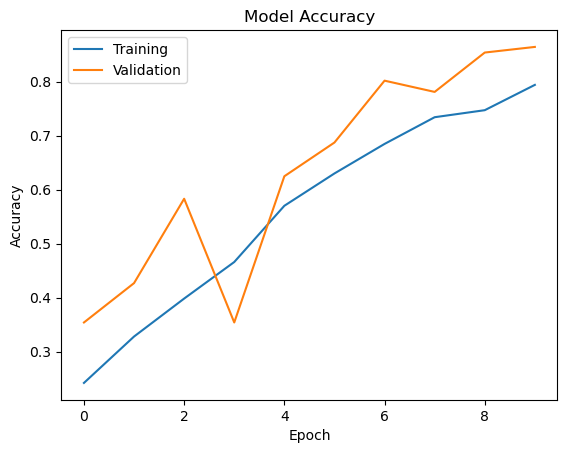

In [13]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

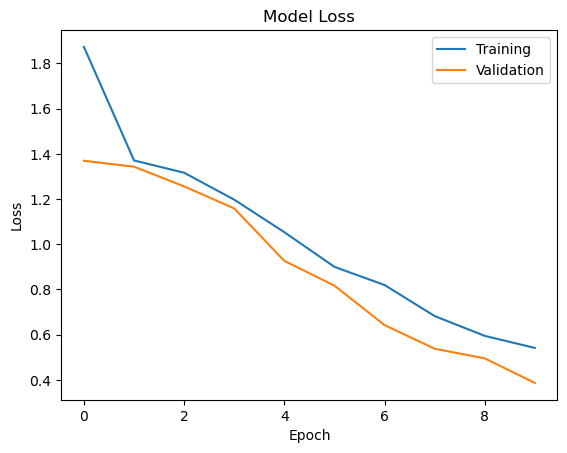

In [14]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Training", "Validation"])

plt.show()

In [15]:
predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step


In [16]:
cm = confusion_matrix(val_data.classes, y_pred)

print(cm)

[[22  0  2  0]
 [ 0 24  0  0]
 [ 3  5 16  0]
 [ 0  0  1 23]]


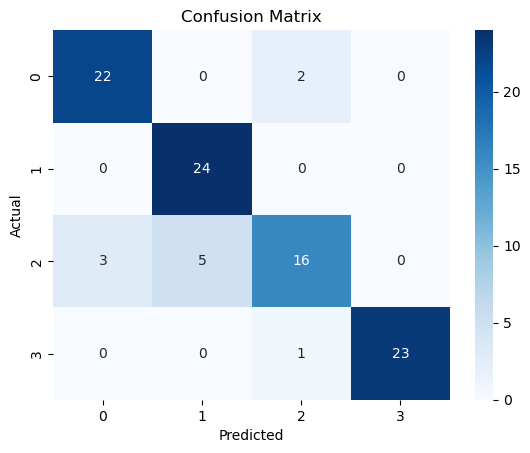

In [17]:
sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [18]:
model.save("manufacturing_defect_cnn.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [19]:
from tensorflow.keras.preprocessing import image

test_image_path = "dent/dent_001.png"

In [20]:
img = image.load_img(

    test_image_path,

    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

In [21]:
prediction = model.predict(img_array)

classes = list(train_data.class_indices.keys())

predicted_class = classes[np.argmax(prediction)]

print("Predicted Class :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Predicted Class : dent


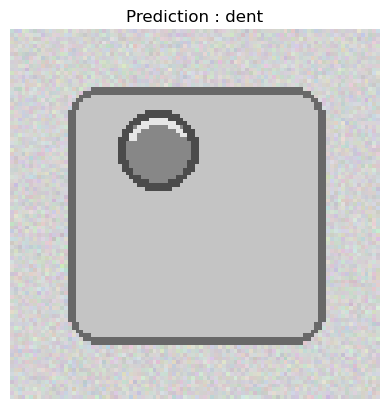

In [22]:
plt.imshow(image.load_img(test_image_path))

plt.title(f"Prediction : {predicted_class}")

plt.axis("off")

plt.show()

## Task 6: CNN Concept Explanation

In [24]:
# CNN Concepts

# What is Convolution?
# Convolution is a mathematical operation where a filter slides over the image to detect features like edges and textures.

# Why Pooling?
# Pooling reduces the size of feature maps, making computation faster and reducing overfitting.

# Why ReLU?
# ReLU replaces negative values with zero, helping the model train faster and avoid vanishing gradients.

# Why CNN over Feedforward Networks?
# CNNs are better because they preserve spatial relationships and use fewer parameters.

## Task 7: Business Use Case

In [26]:
## Business Use Case: Healthcare

# CNN-based image classification can be used to detect diseases from medical images such as X-rays and MRIs.

# Benefits:
# - Faster diagnosis
# - Reduced human error
# - Scalable medical solutions